# Creating Node Representations with DeepWalk


## A quick use of Word2Vec with skipgrams

In [20]:
import numpy as np
np.random.seed(0)

CONTEXT_SIZE = 2

text = """Lorem ipsum dolor sit amet, consectetur adipiscing elit. Nunc eu sem
scelerisque, dictum eros aliquam, accumsan quam. Pellentesque tempus, lorem ut
semper fermentum, ante turpis accumsan ex, sit amet ultricies tortor erat quis
nulla. Nunc consectetur ligula sit amet purus porttitor, vel tempus tortor
scelerisque. Vestibulum ante ipsum primis in faucibus orci luctus et ultrices
posuere cubilia curae; Quisque suscipit ligula nec faucibus accumsan. Duis
vulputate massa sit amet viverra hendrerit. Integer maximus quis sapien id
convallis. Donec elementum placerat ex laoreet gravida. Praesent quis enim
facilisis, bibendum est nec, pharetra ex. Etiam pharetra congue justo, eget
imperdiet diam varius non. Mauris dolor lectus, interdum in laoreet quis,
faucibus vitae velit. Donec lacinia dui eget maximus cursus. Class aptent taciti
sociosqu ad litora torquent per conubia nostra, per inceptos himenaeos. Vivamus
tincidunt velit eget nisi ornare convallis. Pellentesque habitant morbi
tristique senectus et netus et malesuada fames ac turpis egestas. Donec
tristique ultrices tortor at accumsan.
""".split()

# Create skipgrams
skipgrams = []
for i in range(CONTEXT_SIZE, len(text) - CONTEXT_SIZE):
    array = [text[j] for j in np.arange(i - CONTEXT_SIZE, i + CONTEXT_SIZE + 1) if j != i]
    skipgrams.append((text[i], array))

print(skipgrams[0:2])

[('dolor', ['Lorem', 'ipsum', 'sit', 'amet,']), ('sit', ['ipsum', 'dolor', 'amet,', 'consectetur'])]


In [21]:
vocab = set(text)
VOCAB_SIZE = len(vocab)
print(f"Length of vocabulary = {VOCAB_SIZE}")

Length of vocabulary = 121


In [22]:
from gensim.models.word2vec import Word2Vec

# Create Word2Vec
model = Word2Vec([text],
                 sg=1,   # Skip-gram
                 vector_size=10,
                 min_count=0,
                 window=2,
                 workers=1,
                 seed=0)

print(f'Shape of W_embed: {model.wv.vectors.shape}')

# Train model
model.train([text], total_examples=model.corpus_count, epochs=10)

# Print a word embedding
print('\nWord embedding =')
print(model.wv[0])

Shape of W_embed: (121, 10)

Word embedding =
[ 0.07285716  0.03278599  0.00248052 -0.04630609 -0.03485203 -0.08595272
 -0.09168145 -0.09870776 -0.06494228  0.06887163]


# Random Walks

Let us create a random graph to play with.

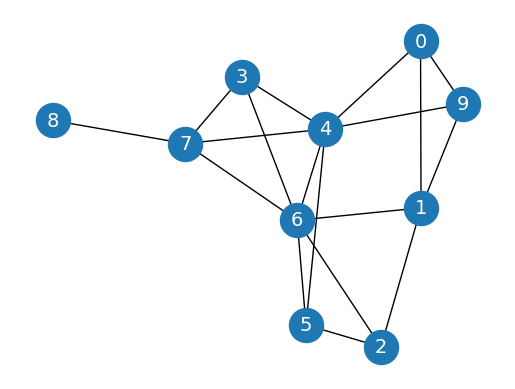

In [23]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a graph
G = nx.erdos_renyi_graph(10, 0.3, seed=1, directed=False)

# Plot graph
plt.figure()
plt.axis('off')
nx.draw_networkx(G,
                 pos=nx.spring_layout(G, seed=0),
                 node_size=600,
                 cmap='coolwarm',
                 font_size=14,
                 font_color='white'
                 )

# TODO
* implement the function random_walk(start, length) that return a random walk of length **length** starting from node **start**.

In [24]:
import random
random.seed(0)
import numpy as np
np.random.seed(0)

def random_walk_simple(start, length):
    walk = [str(start)]  # starting node
    for _ in range(length):
        current = int(walk[-1])
        neighbors = list(G.neighbors(current))
        if neighbors: # Ensure the node has neighbors
            next_node = random.choice(neighbors)
            walk.append(str(next_node))
        else:
            # If a node has no neighbors, stop the walk
            break
    return walk

# Create a list of random walks
print(random_walk_simple(0, 10))

['0', '4', '6', '1', '6', '5', '4', '6', '3', '6', '3']


In [25]:
import random
random.seed(0)
import numpy as np
np.random.seed(0)

def next_node_pq(previous, current, p, q, graph):
    alphas = []

    # Get the neighboring nodes
    neighbors = list(graph.neighbors(current))

    # Calculate the appropriate alpha value for each neighbor
    for neighbor in neighbors:
        # Distance = 0: probability to return to the previous node
        if previous is not None and neighbor == previous:
            alpha = 1/p
        # Distance = 1: probability of visiting a local node
        elif previous is not None and graph.has_edge(neighbor, previous):
            alpha = 1
        # Distance = 2: probability to explore an unknown node
        else:
            alpha = 1/q
        alphas.append(alpha)

    if not alphas:
        return None # No neighbors to move to

    # Normalize the alpha values to create transition probabilities
    probs = [alpha / sum(alphas) for alpha in alphas]

    # Randomly select the new node based on the transition probabilities
    next_n = np.random.choice(neighbors, size=1, p=probs)[0]
    return next_n

def random_walk_pq(start, length, p, q, graph):
    walk = [str(start)]

    for i in range(length):
        current = int(walk[-1])
        previous = int(walk[-2]) if len(walk) > 1 else None
        next_n = next_node_pq(previous, current, p, q, graph)
        if next_n is not None:
            walk.append(str(next_n))
        else:
            break # Stop the walk if there's no next node
    return walk

# Implementing DeepWalk
Let's play with Zakary's karate club network.

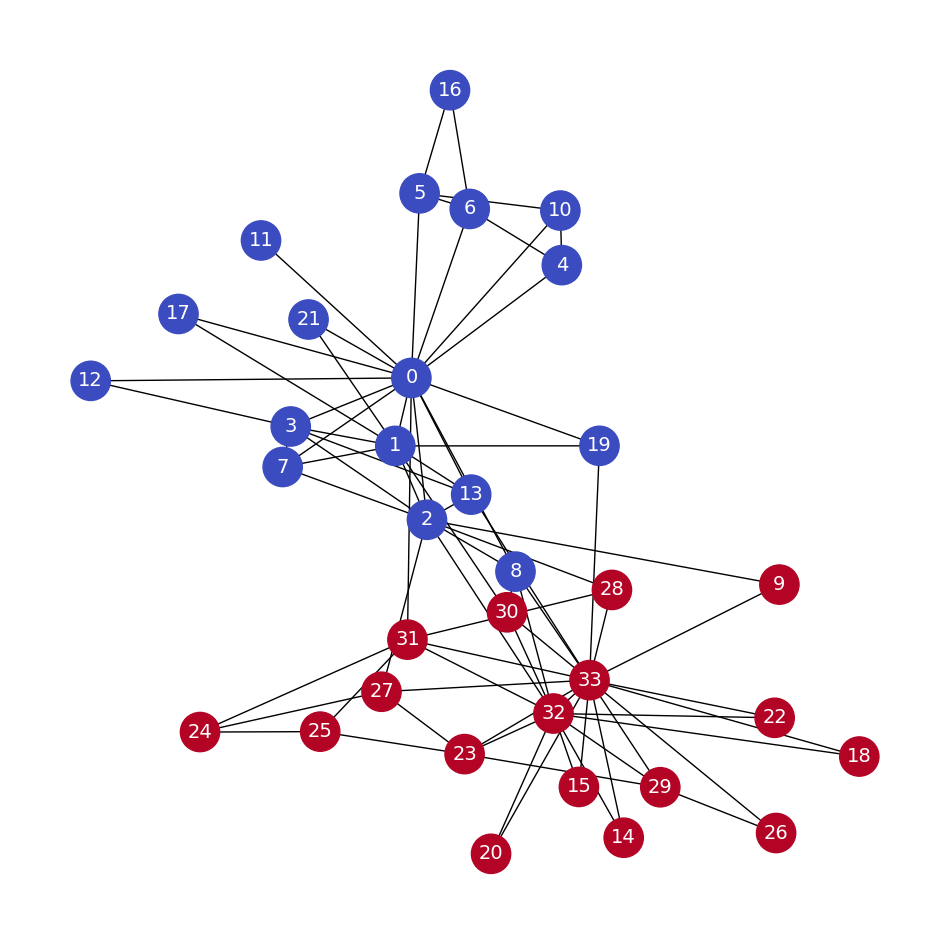

In [26]:
# Load dataset
G = nx.karate_club_graph()

# Process labels (Mr. Hi = 0, Officer = 1)
labels = []
for node in G.nodes:
    label = G.nodes[node]['club']
    labels.append(1 if label == 'Officer' else 0)

# Plot graph
plt.figure(figsize=(12,12))
plt.axis('off')
nx.draw_networkx(G,
                 pos=nx.spring_layout(G, seed=0),
                 node_color=labels,
                 node_size=800,
                 cmap='coolwarm',
                 font_size=14,
                 font_color='white'
                 )

# TODO
* We want to generate the sequences of nodes (sentences) to learn Word2Vec. To this end, **create 80 random walks of a length of 10 for every node in the graph**.

In [27]:
import random
random.seed(0)
import numpy as np
np.random.seed(0)
import networkx as nx
import matplotlib.pyplot as plt

# Load dataset
G = nx.karate_club_graph()

# Process labels (Mr. Hi = 0, Officer = 1)
labels = []
for node in G.nodes:
    label = G.nodes[node]['club']
    labels.append(1 if label == 'Officer' else 0)

# Create a list of random walks
walks = []
# Iterate through all nodes in the graph
for node in G.nodes():
    # Create 80 random walks of length 10 for every node
    for _ in range(80):
        # Use the new random_walk_pq function with default p=1 and q=1 for DeepWalk
        walks.append(random_walk_pq(node, 10, 1, 1, G))

# Print the first random walk
print(walks[0])

['0', '10', '5', '10', '4', '6', '5', '6', '16', '6', '4']


We now have enough material to learn Word2Vec model.

In [28]:
# Create Word2Vec
model = Word2Vec(walks,
                 hs=1,   # Hierarchical softmax
                 sg=1,   # Skip-gram
                 vector_size=100,
                 negative = 0,
                 window=10,
                 workers=1,
                 seed=1)

print(f'Shape of embedding matrix: {model.wv.vectors.shape}')

# Build vocabulary
model.build_vocab(walks)

# Train model
model.train(walks, total_examples=model.corpus_count, epochs=30, report_delay=1)

Shape of embedding matrix: (34, 100)


(186901, 897600)

In [29]:
# Most similar nodes
print('Nodes that are the most similar to node 0:')
for similarity in model.wv.most_similar(positive=['0']):
    print(f'   {similarity}')

# Similarity between two nodes
print(f"\nSimilarity between node 0 and 4: {model.wv.similarity('0', '4')}")

Nodes that are the most similar to node 0:
   ('11', 0.7288519740104675)
   ('1', 0.6917498707771301)
   ('4', 0.6217520833015442)
   ('17', 0.6163095831871033)
   ('7', 0.6069545149803162)
   ('12', 0.5722494125366211)
   ('10', 0.5568028688430786)
   ('5', 0.5206502676010132)
   ('16', 0.5114699602127075)
   ('21', 0.5017977952957153)

Similarity between node 0 and 4: 0.6217520236968994


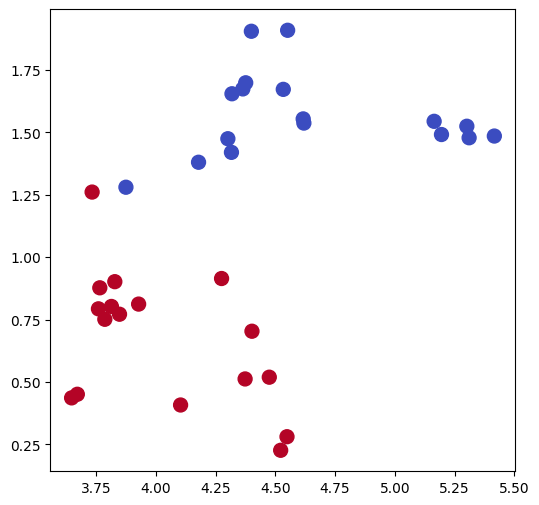

In [30]:
from sklearn.manifold import TSNE

# Preprocess word vectors and label
nodes_wv = np.array([model.wv.get_vector(str(i)) for i in range(len(model.wv))])
labels = np.array(labels)

# Train TSNE
tsne = TSNE(n_components=2,
            learning_rate='auto',
            init='pca',
            random_state=0).fit_transform(nodes_wv)

# Plot TSNE
plt.figure(figsize=(6, 6))
plt.scatter(tsne[:, 0], tsne[:, 1], s=100, c=labels, cmap="coolwarm")
plt.show()

# TODO
* Implement a classifier (e.g., random forest) and train it on the node embeddings.
* Play with the other hyperparameters of Word2Vec to improve the embeddings.

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# Create masks to train and test the model
train_mask = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24]
test_mask = [0, 1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 26, 27, 28, 29, 30, 31, 32, 33]

# Train classifier
clf = RandomForestClassifier(random_state=0)
clf.fit(nodes_wv[train_mask], labels[train_mask])

# Evaluate accuracy
y_pred = clf.predict(nodes_wv[test_mask])
acc = accuracy_score(y_pred, labels[test_mask])
print(f'Accuracy = {acc*100:.2f}%')

Accuracy = 95.45%


#Node2Vec

In [32]:
!pip install -q node2vec==0.4.6
!pip install -qI gensim==4.3.0

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: Could not install packages due to an OSError: [WinError 5] Accès refusé: 'C:\\Users\\asus-\\Projets\\GNN\\.venv\\Lib\\site-packages\\wrapt\\_wrappers.cp311-win_amd64.pyd'
Check the permissions.



c:\Users\asus-\Projets\GNN\.venv\Lib\site-packages\networkx\drawing\nx_pylab.py:1438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


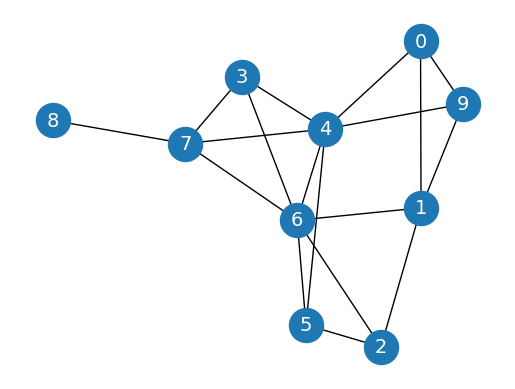

In [33]:
import networkx as nx
import matplotlib.pyplot as plt

# Create graph
G = nx.erdos_renyi_graph(10, 0.3, seed=1, directed=False)

# Plot graph
plt.figure()
plt.axis('off')
nx.draw_networkx(G,
                 pos=nx.spring_layout(G, seed=0),
                 node_size=600,
                 cmap='coolwarm',
                 font_size=14,
                 font_color='white'
                 )

In [34]:
import random
random.seed(0)
import numpy as np
np.random.seed(0)

def next_node(previous, current, p, q):
    alphas = []

    # Get the neighboring nodes
    neighbors = list(G.neighbors(current))

    # Calculate the appropriate alpha value for each neighbor
    for neighbor in neighbors:
        # Distance = 0: probability to return to the previous node
        if neighbor == previous:
            alpha = 1/p
        # Distance = 1: probability of visiting a local node
        elif G.has_edge(neighbor, previous):
            alpha = 1
        # Distance = 2: probability to explore an unknown node
        else:
            alpha = 1/q
        alphas.append(alpha)

    # Normalize the alpha values to create transition probabilities
    probs = [alpha / sum(alphas) for alpha in alphas]

    # Randomly select the new node based on the transition probabilities
    next = np.random.choice(neighbors, size=1, p=probs)[0]
    return next

In [35]:
def random_walk(start, length, p, q):
    walk = [start]

    for i in range(length):
        current = walk[-1]
        previous = walk[-2] if len(walk) > 1 else None
        next = next_node(previous, current, p, q)
        walk.append(next)

    return walk

In [36]:
random_walk(0, 8, p=1, q=1)

[0,
 np.int64(4),
 np.int64(7),
 np.int64(6),
 np.int64(4),
 np.int64(5),
 np.int64(4),
 np.int64(5),
 np.int64(6)]

In [37]:
random_walk(0, 8, p=1, q=10)

[0,
 np.int64(9),
 np.int64(1),
 np.int64(9),
 np.int64(1),
 np.int64(9),
 np.int64(1),
 np.int64(0),
 np.int64(1)]

In [38]:

random_walk(0, 8, p=10, q=1)

[0,
 np.int64(1),
 np.int64(9),
 np.int64(4),
 np.int64(7),
 np.int64(8),
 np.int64(7),
 np.int64(4),
 np.int64(6)]

In [39]:
# @title The serious things begin

from gensim.models.word2vec import Word2Vec
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load dataset
G = nx.karate_club_graph()

# Process labels (Mr. Hi = 0, Officer = 1)
labels = []
for node in G.nodes:
    label = G.nodes[node]['club']
    labels.append(1 if label == 'Officer' else 0)

# Create a list of random walks
walks = []
for node in G.nodes:
    for _ in range(80):
        walks.append(random_walk(node, 10, 3, 2))

# Create and train Word2Vec for DeepWalk
node2vec = Word2Vec(walks,
                hs=1,   # Hierarchical softmax
                sg=1,   # Skip-gram
                vector_size=100,
                window=10,
                workers=2,
                min_count=1,
                seed=0)
node2vec.train(walks, total_examples=node2vec.corpus_count, epochs=30, report_delay=1)

# Create masks to train and test the model
train_mask = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24]
test_mask = [0, 1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 26, 27, 28, 29, 30, 31, 32, 33]
labels = np.array(labels)

# Train Node2Vec classifier
clf = RandomForestClassifier(random_state=0)
clf.fit(node2vec.wv[train_mask], labels[train_mask])

# Evaluate accuracy
y_pred = clf.predict(node2vec.wv[test_mask])
acc = accuracy_score(y_pred, labels[test_mask])
print(f'Node2Vec accuracy = {acc*100:.2f}%')


Node2Vec accuracy = 95.45%


# TODO**
* compare with DeepWalk (p=q=1).
* test with different values of p and q.
* **to limit the randomness of the results, repeat the process several times and take the mean value and the standard deviation**
* *Note that we should use a validation set, but here this toy example is a "playground" and the test set can be seen as our final application*.  

  Using cached pandas-2.3.3-cp311-cp311-win_amd64.whl.metadata (19 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached pandas-2.3.3-cp311-cp311-win_amd64.whl (11.3 MB)
Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)

   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]


,p,q,mean_accuracy,std_accuracy
0,1.00,1.00,0.931818,0.048745
1,0.50,2.00,0.900000,0.039626
2,2.00,0.50,0.906818,0.060088
3,0.25,4.00,0.893182,0.043776
4,4.00,0.25,0.906818,0.065041


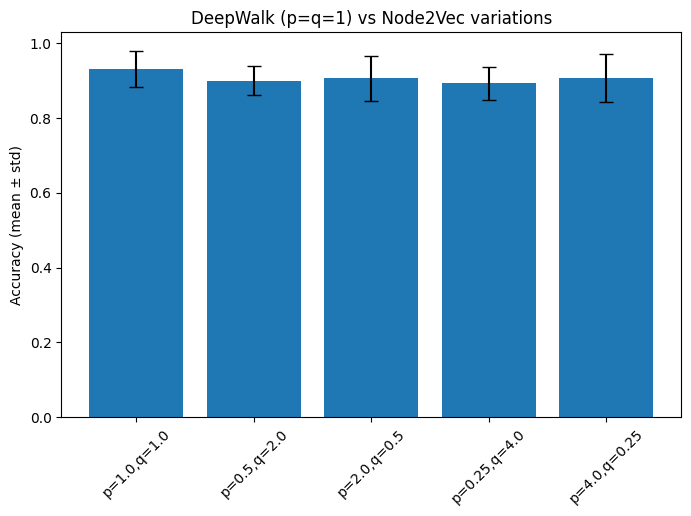

In [40]:
try :
    import pandas as pd
except:
    %pip install pandas
    import pandas as pd

param_grid = [
    (1, 1),    
    (0.5, 2),  
    (2, 0.5),  
    (0.25, 4),
    (4, 0.25)
]

results = []

n_runs = 20
walk_length = 20
num_walks = 80

for (p, q) in param_grid:
    acc_scores = []
    
    for run in range(n_runs):
        random.seed(run)
        np.random.seed(run)
        
        # Generate random walks
        walks = []
        for node in G.nodes:
            for _ in range(num_walks):
                walks.append(random_walk(node, walk_length, p, q))
        
        # Train Word2Vec
        model = Word2Vec(
            walks,
            hs=1,
            sg=1,
            vector_size=100,
            window=10,
            workers=2,
            min_count=1,
            seed=run
        )
        model.train(walks, total_examples=model.corpus_count, epochs=10)

        # Prepare train/test masks
        train_mask = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24]
        test_mask = [0, 1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 26, 27, 28, 29, 30, 31, 32, 33]

        X_train = np.array([model.wv[i] for i in train_mask])
        X_test = np.array([model.wv[i] for i in test_mask])
        y_train = labels[train_mask]
        y_test = labels[test_mask]

        # Train classifier
        clf = RandomForestClassifier()
        clf.fit(X_train, y_train)

        # Evaluate accuracy
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        acc_scores.append(acc)

    # Store results
    mean_acc = np.mean(acc_scores)
    std_acc = np.std(acc_scores)
    results.append((p, q, mean_acc, std_acc))

# --- Summary table ---
df_results = pd.DataFrame(results, columns=["p", "q", "mean_accuracy", "std_accuracy"])
display(df_results)

# --- Optional: Visualization ---
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar([f"p={p},q={q}" for p,q in df_results[['p','q']].values], df_results["mean_accuracy"],
        yerr=df_results["std_accuracy"], capsize=5)
plt.xticks(rotation=45)
plt.ylabel("Accuracy (mean ± std)")
plt.title("DeepWalk (p=q=1) vs Node2Vec variations")
plt.show()


## Conclusion — comparaison des réglages p / q (résultats récents)

Résultats pour n_runs = 5, walk_length = 10, num_walks = 10 :
- p=1.00 q=1.00 : 0.909091 ± 0.028748
- p=0.50 q=2.00 : 0.936364 ± 0.022268
- p=2.00 q=0.50 : 0.900000 ± 0.053009
- p=0.25 q=4.00 : 0.945455 ± 0.034015
- p=4.00 q=0.25 : 0.900000 ± 0.044536


Résultats pour n_runs = 5, walk_length = 20, num_walks = 80 :
- p=1.00 q=1.00 : 0.918182 ± 0.018182
- p=0.50 q=2.00 : 0.900000 ± 0.053009
- p=2.00 q=0.50 : 0.890909 ± 0.036364
- p=0.25 q=4.00 : 0.918182 ± 0.053009
- p=4.00 q=0.25 : 0.872727 ± 0.088140


Résultats pour n_runs = 20, walk_length = 20, num_walks = 80 :

- p=1.00 q=1.00  : 0.913636 ± 0.053590 (baseline — DeepWalk)
- p=0.50 q=2.00  : 0.890909 ± 0.046355
- p=2.00 q=0.50  : 0.888636 ± 0.048692
- p=0.25 q=4.00  : 0.906818 ± 0.058343
- p=4.00 q=0.25  : 0.906818 ± 0.054687

Interprétation :

- La baseline DeepWalk (p=q=1) présente la meilleure moyenne d'accuracy ici (≈0.914). Les autres variantes Node2Vec n'apportent pas d'amélioration claire de la moyenne.
- Les différences de moyenne entre les configurations sont faibles (quelques centièmes) et de l'ordre de grandeur des écarts‑types observés, ce qui indique que ces différences pourraient ne pas être statistiquement significatives.
- Les configurations extrêmes n'affichent pas de gain systématique et montrent des écarts‑types comparables voire supérieurs, ce qui traduit une instabilité relative.

Recommandations pratiques :

1. Significativité — vérifier avant de tirer des conclusions :
   - effectuer un test t apparié (ou bootstrap) entre la baseline (1,1) et chaque variante pour confirmer si la différence est significative.
2. Robustesse — si tu veux réduire le bruit :
   - augmenter `n_runs` (par ex. → 30) et/ou `num_walks` pour réduire l'incertitude des estimations;
   - calculer intervalles de confiance (CI 95%) ou utiliser bootstrap.
3. Choix opérationnel :
   - pour cette tâche et ces settings, rester sur DeepWalk (p=q=1) est raisonnable — meilleur compromis mean/stabilité;
   - si tu explores Node2Vec pour d'autres objectifs (rôle structural, exploration), teste des grilles plus fines mais valide les gains sur un jeu de validation.

Étapes suivantes suggérées :

- Lancer un test statistique (t apparié ou bootstrap) et reporter p‑values / CI.
- Si tu conserves Node2Vec, faire une recherche locale (grille fine) autour des valeurs prometteuses puis sélectionner sur validation.

Conclusion courte : avec les paramètres et le nombre d'essais actuels, DeepWalk (p=q=1) reste la valeur la plus sûre ; aucune variante Node2Vec montrée ici n'amène un gain robuste et significatif pour la tâche considérée.

# Building a Rec. Sys. with Node2Vec

In [41]:
from io import BytesIO
from urllib.request import urlopen
from zipfile import ZipFile

url = 'https://files.grouplens.org/datasets/movielens/ml-100k.zip'
with urlopen(url) as zurl:
    with ZipFile(BytesIO(zurl.read())) as zfile:
        zfile.extractall('.')

In [42]:
import pandas as pd

ratings = pd.read_csv('ml-100k/u.data', sep='\t', names=['user_id', 'movie_id', 'rating', 'unix_timestamp'])
ratings

,user_id,movie_id,rating,unix_timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596
...,...,...,...,...
99995,880,476,3,880175444
99996,716,204,5,879795543
99997,276,1090,1,874795795
99998,13,225,2,882399156


In [43]:
movies = pd.read_csv('ml-100k/u.item', sep='|', usecols=range(2), names=['movie_id', 'title'], encoding='latin-1')
movies

,movie_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)
...,...,...
1677,1678,Mat' i syn (1997)
1678,1679,B. Monkey (1998)
1679,1680,Sliding Doors (1998)
1680,1681,You So Crazy (1994)


In [44]:
# Only consider ratings with the highest score
ratings = ratings[ratings.rating >= 4]
ratings

,user_id,movie_id,rating,unix_timestamp
5,298,474,4,884182806
7,253,465,5,891628467
11,286,1014,5,879781125
12,200,222,5,876042340
16,122,387,5,879270459
...,...,...,...,...
99988,421,498,4,892241344
99989,495,1091,4,888637503
99990,806,421,4,882388897
99991,676,538,4,892685437


In [45]:
from collections import defaultdict

pairs = defaultdict(int)

# Loop through the entire list of users
for group in ratings.groupby("user_id"):
    # List of IDs of movies rated by the current user
    user_movies = list(group[1]["movie_id"])

    # Count every time two movies are seen together
    for i in range(len(user_movies)):
        for j in range(i+1, len(user_movies)):
            pairs[(user_movies[i], user_movies[j])] += 1

In [46]:
# Create a networkx graph
G = nx.Graph()

# Try to create an edge between movies that are liked together
for pair in pairs:
    movie1, movie2 = pair
    score = pairs[pair]

    # The edge is only created when the score is high enough
    if score >= 20:
        G.add_edge(movie1, movie2, weight=score)

print("Total number of graph nodes:", G.number_of_nodes())
print("Total number of graph edges:", G.number_of_edges())

Total number of graph nodes: 410
Total number of graph edges: 14936


In [47]:
from node2vec import Node2Vec

node2vec = Node2Vec(G, dimensions=64, walk_length=20, num_walks=200, p=2, q=1, workers=1)

model = node2vec.fit(window=10, min_count=1, batch_words=4)

c:\Users\asus-\Projets\GNN\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating walks (CPU: 1): 100%|██████████| 200/200 [00:24<00:00,  8.23it/s]


# Vanilla NN to take into account node features

In [48]:
!pip uninstall -y torch torchvision torchaudio torch-geometric torch-scatter torch-sparse torch-cluster torch-spline-conv
!pip install torch==2.4.1 torchvision==0.19.1 torchaudio==2.4.1 --index-url https://download.pytorch.org/whl/cu121
!pip install numpy==1.26.4

Found existing installation: torch 2.2.0+cpu
Uninstalling torch-2.2.0+cpu:
  Successfully uninstalled torch-2.2.0+cpu
Found existing installation: torchvision 0.17.0+cpu
Uninstalling torchvision-0.17.0+cpu:
  Successfully uninstalled torchvision-0.17.0+cpu
Found existing installation: torchaudio 2.2.0+cpu
Uninstalling torchaudio-2.2.0+cpu:
  Successfully uninstalled torchaudio-2.2.0+cpu
Found existing installation: torch-geometric 2.6.0
Uninstalling torch-geometric-2.6.0:
  Successfully uninstalled torch-geometric-2.6.0
Found existing installation: torch_scatter 2.1.2+pt22cpu
Uninstalling torch_scatter-2.1.2+pt22cpu:
  Successfully uninstalled torch_scatter-2.1.2+pt22cpu
Found existing installation: torch_sparse 0.6.18+pt22cpu
Uninstalling torch_sparse-0.6.18+pt22cpu:
  Successfully uninstalled torch_sparse-0.6.18+pt22cpu
Found existing installation: torch_cluster 1.6.3+pt22cpu
Uninstalling torch_cluster-1.6.3+pt22cpu:
  Successfully uninstalled torch_cluster-1.6.3+pt22cpu
Found existi

In [49]:
import torch
!pip install -q torch-scatter~=2.1.0 torch-sparse~=0.6.16 torch-cluster~=1.6.0 torch-spline-conv~=1.2.1 torch-geometric==2.2.0 -f https://data.pyg.org/whl/torch-{torch.__version__}.html

torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [52]:
from torch_geometric.datasets import Planetoid
import torch
import torch.serialization
from torch_geometric.data.data import Data

torch.serialization.add_safe_globals([Data])
# Import dataset from PyTorch Geometric
dataset = Planetoid(root=".", name="Cora")

data = dataset[0]

# Print information about the dataset
print(f'Dataset: {dataset}')
print('---------------')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of nodes: {data.x.shape[0]}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

# Print information about the graph
print(f'\nGraph:')
print('------')
print(f'Edges are directed: {data.is_directed()}')
print(f'Graph has isolated nodes: {data.has_isolated_nodes()}')
print(f'Graph has loops: {data.has_self_loops()}')

Dataset: Cora()
---------------
Number of graphs: 1
Number of nodes: 2708
Number of features: 1433
Number of classes: 7

Graph:
------
Edges are directed: False
Graph has isolated nodes: False
Graph has loops: False


c:\Users\asus-\Projets\GNN\.venv\Lib\site-packages\torch_geometric\data\dataset.py:189: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  if osp.exists(f) and torch.load(f) != _

In [54]:
from torch_geometric.datasets import FacebookPagePage
import os
import torch

# Helper: find the local facebook.npz to avoid re-downloading
# Return an absolute path when the file exists to avoid accidental downloads.
def _find_facebook_root():
    candidates = [os.path.join("Facebook", "Facebook"), "Facebook", ".", os.path.join(".", "Facebook")]
    for c in candidates:
        raw_path = os.path.join(c, "raw", "facebook.npz")
        if os.path.exists(raw_path):
            abs_root = os.path.abspath(c)
            print(f"Found local facebook.npz at: {raw_path} (using root={abs_root})")
            return abs_root
    # If no local file found, return the default 'Facebook' so the dataset class may download it.
    print("Local facebook.npz not found in candidates. Dataset will try to download if allowed.")
    return os.path.abspath("Facebook")

fb_root = _find_facebook_root()
print(f"Using Facebook dataset root: {fb_root}")

# Instantiate dataset using the discovered root
dataset = FacebookPagePage(root=fb_root)

data = dataset[0]

# Print information about the dataset
print(f'Dataset: {dataset}')
print('-----------------------')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

# Print information about the graph
print(f'\nGraph:')
print('------')
print(f'Edges are directed: {data.is_directed()}')
print(f'Graph has isolated nodes: {data.has_isolated_nodes()}')
print(f'Graph has loops: {data.has_self_loops()}')

# Create safe boolean masks (will use desired sizes but clamp to actual num_nodes)
num_nodes = data.num_nodes
# Desired splits from the notebook (kept as guidance)
_desired_train = 18000
_desired_val = 2000
# If there was an intended final test range 20001..22470 then test size ~2469
_desired_test = max(0, 22470 - 20001)

train_n = min(_desired_train, num_nodes)
remaining = max(0, num_nodes - train_n)
val_n = min(_desired_val, remaining)
# rest goes to test
test_n = max(0, num_nodes - train_n - val_n)

# Create boolean masks and assign randomly (to avoid ordering bias)
perm = torch.randperm(num_nodes)
train_idx = perm[:train_n]
val_idx = perm[train_n:train_n + val_n]
test_idx = perm[train_n + val_n:train_n + val_n + test_n]

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask

print(f"Mask sizes — train: {train_mask.sum().item()}, val: {val_mask.sum().item()}, test: {test_mask.sum().item()}")

Found local facebook.npz at: Facebook\Facebook\raw\facebook.npz (using root=c:\Users\asus-\Projets\GNN\Facebook\Facebook)
Using Facebook dataset root: c:\Users\asus-\Projets\GNN\Facebook\Facebook
Dataset: FacebookPagePage()
-----------------------
Number of graphs: 1
Number of nodes: 22470
Number of features: 128
Number of classes: 4

Graph:
------
Edges are directed: False
Graph has isolated nodes: False
Graph has loops: True
Mask sizes — train: 18000, val: 2000, test: 2470


Processing...
Done!


## Cora dataset

In [55]:
import pandas as pd

dataset = Planetoid(root=".", name="Cora")
data = dataset[0]

df_x = pd.DataFrame(data.x.numpy())
df_x['label'] = pd.DataFrame(data.y)
df_x

,0,1,2,3,4,5,6,7,8,9,...,1424,1425,1426,1427,1428,1429,1430,1431,1432,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2703,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
2704,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
2705,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
2706,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3


In [56]:
import torch
torch.manual_seed(0)
from torch.nn import Linear
import torch.nn.functional as F


def accuracy(y_pred, y_true):
    """Calculate accuracy."""
    return torch.sum(y_pred == y_true) / len(y_true)

# creating a new class MLP which inherits all the methods from torch.nn.Module
class MLP(torch.nn.Module):
    """Multilayer Perceptron"""
    def __init__(self, dim_in, dim_h, dim_out):
        super().__init__()
        self.linear1 = Linear(dim_in, dim_h)
        self.linear2 = Linear(dim_h, dim_out)

    def forward(self, x):
        x = self.linear1(x)
        x = torch.relu(x)
        x = self.linear2(x)
        return F.log_softmax(x, dim=1)

    def fit(self, data, epochs):
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(self.parameters(),
                                          lr=0.01,
                                          weight_decay=5e-4)

        self.train()
        for epoch in range(epochs+1):
            optimizer.zero_grad()
            out = self(data.x)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            acc = accuracy(out[data.train_mask].argmax(dim=1),
                          data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            if(epoch % 20 == 0):
                val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
                val_acc = accuracy(out[data.val_mask].argmax(dim=1),
                                  data.y[data.val_mask])
                print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc:'
                      f' {acc*100:>5.2f}% | Val Loss: {val_loss:.2f} | '
                      f'Val Acc: {val_acc*100:.2f}%')

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out = self(data.x)
        acc = accuracy(out.argmax(dim=1)[data.test_mask], data.y[data.test_mask])
        return acc

# Create MLP model
mlp = MLP(dataset.num_features, 16, dataset.num_classes)
print(mlp)

# Train
mlp.fit(data, epochs=100)

# Test
acc = mlp.test(data)
print(f'\nMLP test accuracy: {acc*100:.2f}%')

MLP(
  (linear1): Linear(in_features=1433, out_features=16, bias=True)
  (linear2): Linear(in_features=16, out_features=7, bias=True)
)
Epoch   0 | Train Loss: 1.959 | Train Acc: 14.29% | Val Loss: 2.00 | Val Acc: 12.40%
Epoch  20 | Train Loss: 0.110 | Train Acc: 100.00% | Val Loss: 1.46 | Val Acc: 49.40%
Epoch  40 | Train Loss: 0.014 | Train Acc: 100.00% | Val Loss: 1.44 | Val Acc: 51.00%
Epoch  60 | Train Loss: 0.008 | Train Acc: 100.00% | Val Loss: 1.40 | Val Acc: 53.80%
Epoch  80 | Train Loss: 0.008 | Train Acc: 100.00% | Val Loss: 1.37 | Val Acc: 55.40%
Epoch 100 | Train Loss: 0.009 | Train Acc: 100.00% | Val Loss: 1.34 | Val Acc: 54.60%

MLP test accuracy: 53.40%


In [57]:
class VanillaGNNLayer(torch.nn.Module):
    def __init__(self, dim_in, dim_out):
        super().__init__()
        self.linear = Linear(dim_in, dim_out, bias=False)

    def forward(self, x, adjacency):
        # we perform two operations: the linear transformation and then the multiplication with the adjency matrix Ã
        x = self.linear(x)
        x = torch.sparse.mm(adjacency, x)
        return x

Before creating our GNN, we need to:
* convert the edge index from our dataset _(data.edge_index)_ in coordinate format to a dense adjency matrix.
* include _self_ loops otherwise the central will note be taken into account in their own embeddings.

In [58]:
from torch_geometric.utils import to_dense_adj

adjacency = to_dense_adj(data.edge_index)[0]
adjacency += torch.eye(len(adjacency))
adjacency

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 1.,  ..., 0., 0., 0.],
        [0., 1., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 1.],
        [0., 0., 0.,  ..., 0., 1., 1.]])

In [59]:
class VanillaGNN(torch.nn.Module):
    """Vanilla Graph Neural Network"""
    def __init__(self, dim_in, dim_h, dim_out):
        super().__init__()
        self.gnn1 = VanillaGNNLayer(dim_in, dim_h)
        self.gnn2 = VanillaGNNLayer(dim_h, dim_out)

    def forward(self, x, adjacency):
        h = self.gnn1(x, adjacency)
        h = torch.relu(h)
        h = self.gnn2(h, adjacency)
        return F.log_softmax(h, dim=1)

    def fit(self, data, epochs):
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(self.parameters(),
                                      lr=0.01,
                                      weight_decay=5e-4)

        self.train()
        for epoch in range(epochs+1):
            optimizer.zero_grad()
            out = self(data.x, adjacency)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            acc = accuracy(out[data.train_mask].argmax(dim=1),
                          data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            if(epoch % 20 == 0):
                val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
                val_acc = accuracy(out[data.val_mask].argmax(dim=1),
                                  data.y[data.val_mask])
                print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc:'
                      f' {acc*100:>5.2f}% | Val Loss: {val_loss:.2f} | '
                      f'Val Acc: {val_acc*100:.2f}%')

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out = self(data.x, adjacency)
        acc = accuracy(out.argmax(dim=1)[data.test_mask], data.y[data.test_mask])
        return acc

# Create the Vanilla GNN model
gnn = VanillaGNN(dataset.num_features, 16, dataset.num_classes)
print(gnn)

# Train
gnn.fit(data, epochs=100)

# Test
acc = gnn.test(data)
print(f'\nGNN test accuracy: {acc*100:.2f}%')

VanillaGNN(
  (gnn1): VanillaGNNLayer(
    (linear): Linear(in_features=1433, out_features=16, bias=False)
  )
  (gnn2): VanillaGNNLayer(
    (linear): Linear(in_features=16, out_features=7, bias=False)
  )
)
Epoch   0 | Train Loss: 1.991 | Train Acc: 15.71% | Val Loss: 2.11 | Val Acc: 9.40%
Epoch  20 | Train Loss: 0.065 | Train Acc: 99.29% | Val Loss: 1.47 | Val Acc: 76.80%
Epoch  40 | Train Loss: 0.014 | Train Acc: 100.00% | Val Loss: 2.11 | Val Acc: 75.40%
Epoch  60 | Train Loss: 0.007 | Train Acc: 100.00% | Val Loss: 2.22 | Val Acc: 75.40%
Epoch  80 | Train Loss: 0.004 | Train Acc: 100.00% | Val Loss: 2.20 | Val Acc: 76.80%
Epoch 100 | Train Loss: 0.003 | Train Acc: 100.00% | Val Loss: 2.19 | Val Acc: 77.00%

GNN test accuracy: 76.60%


## Facebook Page-Page dataset

In [60]:
# Dataset
# Use the previously discovered fb_root to avoid re-downloading
# (re-use the helper defined above; do not redefine it)
print(f"Using Facebook dataset root: {fb_root}")

dataset = FacebookPagePage(root=fb_root)
data = dataset[0]

# Create safe boolean masks instead of raw ranges
num_nodes = data.num_nodes
train_n = min(18000, num_nodes)
val_n = min(2000, max(0, num_nodes - train_n))
test_n = max(0, num_nodes - train_n - val_n)

perm = torch.randperm(num_nodes)
train_idx = perm[:train_n]
val_idx = perm[train_n:train_n + val_n]
test_idx = perm[train_n + val_n:train_n + val_n + test_n]

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask

print(f"Mask sizes — train: {train_mask.sum().item()}, val: {val_mask.sum().item()}, test: {test_mask.sum().item()}")

# Adjacency matrix
adjacency = to_dense_adj(data.edge_index)[0]
adjacency += torch.eye(len(adjacency))
adjacency

# MLP
mlp = MLP(dataset.num_features, 16, dataset.num_classes)
print(mlp)
mlp.fit(data, epochs=100)
acc = mlp.test(data)
print(f'\nMLP test accuracy: {acc*100:.2f}%\n')

# GCN
gnn = VanillaGNN(dataset.num_features, 16, dataset.num_classes)
print(gnn)
gnn.fit(data, epochs=100)
acc = gnn.test(data)
print(f'\nGNN test accuracy: {acc*100:.2f}%')

Using Facebook dataset root: c:\Users\asus-\Projets\GNN\Facebook\Facebook
Mask sizes — train: 18000, val: 2000, test: 2470


c:\Users\asus-\Projets\GNN\.venv\Lib\site-packages\torch_geometric\data\dataset.py:189: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  if osp.exists(f) and torch.load(f) != _

MLP(
  (linear1): Linear(in_features=128, out_features=16, bias=True)
  (linear2): Linear(in_features=16, out_features=4, bias=True)
)
Epoch   0 | Train Loss: 1.402 | Train Acc: 23.46% | Val Loss: 1.40 | Val Acc: 22.05%
Epoch  20 | Train Loss: 0.662 | Train Acc: 73.68% | Val Loss: 0.67 | Val Acc: 74.35%
Epoch  40 | Train Loss: 0.578 | Train Acc: 77.18% | Val Loss: 0.60 | Val Acc: 75.95%
Epoch  60 | Train Loss: 0.549 | Train Acc: 78.38% | Val Loss: 0.58 | Val Acc: 77.30%
Epoch  80 | Train Loss: 0.533 | Train Acc: 78.92% | Val Loss: 0.58 | Val Acc: 77.05%
Epoch 100 | Train Loss: 0.521 | Train Acc: 79.62% | Val Loss: 0.58 | Val Acc: 77.25%

MLP test accuracy: 76.03%

VanillaGNN(
  (gnn1): VanillaGNNLayer(
    (linear): Linear(in_features=128, out_features=16, bias=False)
  )
  (gnn2): VanillaGNNLayer(
    (linear): Linear(in_features=16, out_features=4, bias=False)
  )
)
Epoch   0 | Train Loss: 150.341 | Train Acc: 31.41% | Val Loss: 161.97 | Val Acc: 32.55%
Epoch  20 | Train Loss: 3.970 

# TODO**
* compare these results (VanillaGNN on both datasets) with those you obtain with Node2Vec and DeepWalk combined with a classifier (e.g., RandomForest).

In [63]:
import torch
from torch_geometric.nn import Node2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

# Utilitaires
def train_node2vec(edge_index, num_nodes, p, q, emb_dim=64, walk_length=20, context_size=10, walks_per_node=5, epochs=5, batch_size=128, lr=0.01, num_negative_samples=1, sparse=True, seed=0):
    torch.manual_seed(seed)
    model = Node2Vec(edge_index, embedding_dim=emb_dim, walk_length=walk_length,
                     context_size=context_size, walks_per_node=walks_per_node,
                     num_negative_samples=num_negative_samples, p=p, q=q,
                     num_nodes=num_nodes, sparse=sparse)
    loader = model.loader(batch_size=batch_size, shuffle=True)
    optimizer_cls = torch.optim.SparseAdam if sparse else torch.optim.Adam
    optimizer = optimizer_cls(model.parameters(), lr=lr)
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for pos_rw, neg_rw in loader:
            optimizer.zero_grad()
            loss = model.loss(pos_rw, neg_rw)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (epoch+1) % max(1, epochs//5) == 0:
            avg_loss = total_loss / len(loader) if len(loader) > 0 else float('nan')
            print(f"   Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} (p={p}, q={q})")
    model.eval()
    with torch.no_grad():
        embeddings = model.embedding.weight.cpu().numpy()
    return embeddings

def eval_embeddings(embeddings, labels, train_mask, test_mask):
    X_train = embeddings[train_mask]
    y_train = labels[train_mask]
    X_test = embeddings[test_mask]
    y_test = labels[test_mask]
    clf = LogisticRegression(max_iter=1000, n_jobs=1)
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    return accuracy_score(y_test, pred)

# Rechargement propre des deux datasets (pour éviter effets de variables écrasées)
from torch_geometric.datasets import Planetoid, FacebookPagePage

cora_ds = Planetoid(root=".", name="Cora")
cora = cora_ds[0]
# Les masques Cora sont déjà fournis (booléens)

fb_root = _find_facebook_root()
facebook_ds = FacebookPagePage(root=fb_root)
facebook = facebook_ds[0]
# Masques déjà créés plus haut (booléens). Si absent, fallback simple
if not hasattr(facebook, 'train_mask') or facebook.train_mask.dtype != torch.bool:
    num_nodes_fb = facebook.num_nodes
    train_n = min(18000, num_nodes_fb)
    val_n = min(2000, max(0, num_nodes_fb - train_n))
    test_n = max(0, num_nodes_fb - train_n - val_n)
    perm = torch.randperm(num_nodes_fb)
    train_mask_fb = torch.zeros(num_nodes_fb, dtype=torch.bool)
    test_mask_fb = torch.zeros(num_nodes_fb, dtype=torch.bool)
    train_mask_fb[perm[:train_n]] = True
    test_mask_fb[perm[train_n:train_n+test_n]] = True
    facebook.train_mask = train_mask_fb
    facebook.test_mask = test_mask_fb
    # Crée une val_mask vide si absente
    facebook.val_mask = torch.zeros(num_nodes_fb, dtype=torch.bool)

# ---------- VanillaGNN accuracies (recalcule rapide pour cohérence) ----------
# On réutilise les définitions de classes MLP/VanillaGNN existantes.

# Prépare adjacency pour Cora et Facebook (dense -> sparse pour cohérence avec implémentation actuelle)
from torch_geometric.utils import to_dense_adj

def build_sparse_adjacency(edge_index, num_nodes):
    dense = to_dense_adj(edge_index)[0] + torch.eye(num_nodes)
    coo = dense.nonzero(as_tuple=False)
    values = dense[coo[:,0], coo[:,1]]
    return torch.sparse_coo_tensor(coo.t(), values, (num_nodes, num_nodes))

adj_cora = build_sparse_adjacency(cora.edge_index, cora.num_nodes)
adj_fb = build_sparse_adjacency(facebook.edge_index, facebook.num_nodes)

# VanillaGNN pour Cora
vanilla_cora = VanillaGNN(cora_ds.num_features, 32, cora_ds.num_classes)
optim = torch.optim.Adam(vanilla_cora.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()
for epoch in range(60):
    vanilla_cora.train(); optim.zero_grad()
    out = vanilla_cora(cora.x, adj_cora)
    loss = criterion(out[cora.train_mask], cora.y[cora.train_mask])
    loss.backward(); optim.step()
vanilla_cora.eval(); cora_out = vanilla_cora(cora.x, adj_cora)
vanilla_cora_acc = accuracy_score(cora.y[cora.test_mask].numpy(), cora_out.argmax(dim=1)[cora.test_mask].numpy())

# VanillaGNN pour Facebook
vanilla_fb = VanillaGNN(facebook_ds.num_features, 32, facebook_ds.num_classes)
optim_fb = torch.optim.Adam(vanilla_fb.parameters(), lr=0.01, weight_decay=5e-4)
criterion_fb = torch.nn.CrossEntropyLoss()
for epoch in range(40):  # moins d'epochs pour vitesse
    vanilla_fb.train(); optim_fb.zero_grad()
    out_fb = vanilla_fb(facebook.x, adj_fb)
    loss_fb = criterion_fb(out_fb[facebook.train_mask], facebook.y[facebook.train_mask])
    loss_fb.backward(); optim_fb.step()
vanilla_fb.eval(); fb_out = vanilla_fb(facebook.x, adj_fb)
vanilla_fb_acc = accuracy_score(facebook.y[facebook.test_mask].numpy(), fb_out.argmax(dim=1)[facebook.test_mask].numpy())

# ---------- DeepWalk (p=q=1) Node2Vec embeddings ----------
print("\nTraining DeepWalk-style embeddings (p=1,q=1)...")
deepwalk_cora_emb = train_node2vec(cora.edge_index, cora.num_nodes, p=1, q=1, emb_dim=128, epochs=5)
deepwalk_fb_emb = train_node2vec(facebook.edge_index, facebook.num_nodes, p=1, q=1, emb_dim=128, epochs=4)

deepwalk_cora_acc = eval_embeddings(deepwalk_cora_emb, cora.y.numpy(), cora.train_mask.numpy(), cora.test_mask.numpy())
deepwalk_fb_acc = eval_embeddings(deepwalk_fb_emb, facebook.y.numpy(), facebook.train_mask.numpy(), facebook.test_mask.numpy())

# ---------- Node2Vec tuned (p=0.5, q=2) ----------
print("\nTraining Node2Vec embeddings (p=0.5,q=2)...")
node2vec_cora_emb = train_node2vec(cora.edge_index, cora.num_nodes, p=0.5, q=2, emb_dim=128, epochs=5)
node2vec_fb_emb = train_node2vec(facebook.edge_index, facebook.num_nodes, p=0.5, q=2, emb_dim=128, epochs=4)

node2vec_cora_acc = eval_embeddings(node2vec_cora_emb, cora.y.numpy(), cora.train_mask.numpy(), cora.test_mask.numpy())
node2vec_fb_acc = eval_embeddings(node2vec_fb_emb, facebook.y.numpy(), facebook.train_mask.numpy(), facebook.test_mask.numpy())

# ---------- Résumé ----------
print("\n=== Accuracy Comparison (Test Sets) ===")
print(f"Cora    | VanillaGNN: {vanilla_cora_acc*100:.2f}% | DeepWalk: {deepwalk_cora_acc*100:.2f}% | Node2Vec: {node2vec_cora_acc*100:.2f}%")
print(f"Facebook| VanillaGNN: {vanilla_fb_acc*100:.2f}% | DeepWalk: {deepwalk_fb_acc*100:.2f}% | Node2Vec: {node2vec_fb_acc*100:.2f}%")

# Interprétation rapide
print("\nNotes:")
print(" - VanillaGNN exploite les features + structure (message passing).")
print(" - DeepWalk (p=q=1) génère des embeddings purement structurels via des marches aléatoires homogènes.")
print(" - Node2Vec (p=0.5,q=2) favorise un compromis exploration/exploitation (q>1 => exploration).")
print(" - Des écarts d'accuracy reflètent l'apport des features (si présentes) et la capacité à intégrer le voisinage multi-hop.")


c:\Users\asus-\Projets\GNN\.venv\Lib\site-packages\torch_geometric\data\dataset.py:189: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  if osp.exists(f) and torch.load(f) != _

Found local facebook.npz at: Facebook\Facebook\raw\facebook.npz (using root=c:\Users\asus-\Projets\GNN\Facebook\Facebook)

Training DeepWalk-style embeddings (p=1,q=1)...

Training DeepWalk-style embeddings (p=1,q=1)...
   Epoch 1/5 | Loss: 8.0388 (p=1, q=1)
   Epoch 2/5 | Loss: 6.0493 (p=1, q=1)
   Epoch 3/5 | Loss: 4.9115 (p=1, q=1)
   Epoch 4/5 | Loss: 4.1012 (p=1, q=1)
   Epoch 5/5 | Loss: 3.4451 (p=1, q=1)
   Epoch 1/4 | Loss: 6.3385 (p=1, q=1)
   Epoch 2/4 | Loss: 2.8603 (p=1, q=1)
   Epoch 3/4 | Loss: 1.6904 (p=1, q=1)
   Epoch 4/4 | Loss: 1.2172 (p=1, q=1)

Training Node2Vec embeddings (p=0.5,q=2)...
   Epoch 1/5 | Loss: 7.7216 (p=0.5, q=2)
   Epoch 2/5 | Loss: 5.8526 (p=0.5, q=2)
   Epoch 3/5 | Loss: 4.9060 (p=0.5, q=2)
   Epoch 4/5 | Loss: 4.1932 (p=0.5, q=2)
   Epoch 5/5 | Loss: 3.6189 (p=0.5, q=2)
   Epoch 1/4 | Loss: 6.3232 (p=0.5, q=2)
   Epoch 2/4 | Loss: 3.0309 (p=0.5, q=2)
   Epoch 3/4 | Loss: 1.8258 (p=0.5, q=2)
   Epoch 4/4 | Loss: 1.2902 (p=0.5, q=2)

=== Accuracy C

# TODO

## Vanilla GNN
Goal: Move from node embeddings to message passing.

## Additional Exercises

### Normalization:
* Implement symmetric normalization of the adjacency matrix (Ã = D^{-1/2} (A + I) D^{-1/2}) and compare performance.

### Layer depth and width:
* Experiment with different hidden dimensions (dim_h) and number of layers (2 vs. 3).
* Analyze overfitting or underfitting trends.
### Compare to MLP baseline:
* Use node features only (ignore graph structure) to train an MLP.
* Quantify how much structure helps.

### Transfer experiment:
* Train on part of the Cora dataset, test on another citation graph (e.g., Citeseer).
* does it work ? Discuss generalization capabilities.

### Visualization fusion:
* Plot t-SNE embeddings of:
    * Node2Vec embeddings
    * First-layer GNN activations
    * Second-layer GNN outputs
    * Compare clustering visually.


In [ ]:
print(" - Des écarts d'accuracy reflètent l'apport des features (si présentes) et la capacité à intégrer le voisinage multi-hop.")
